## Лабораторная 4

1. Сгенерировать набор данных при помощи make_classification из sklearn.
2. Построить нейронную сеть для решения задачи классификации (можете использовать лабораторную 3).
3. Исследовать влияние различных классификаторов на качество модели (SGD, Adam, RMSProp), записать выводы.
4. Добавить к модели метод регуляризации Dropout и повторить пункт 3 уже с ним.

*Дополнительное задание:
Повторить пункты 2-4 для набора данных MNIST.*

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from matplotlib import pyplot as plt
from keras.datasets import mnist

# Генерируем данные методом make_classification

In [2]:
x, y = make_classification(
    n_samples=10000, 
    n_features=50,
    n_informative=30,
    n_redundant=20,
    n_classes=5,
    random_state=1234)
x = StandardScaler().fit_transform(x)
y = np.array(pd.get_dummies(y), dtype="float")

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Обучаем модели для задачи make_classification

In [4]:
# Обучаем модели без Dropout

histories = {}
optimizers = {"SGD": keras.optimizers.SGD(learning_rate=0.01),
              "Adam": keras.optimizers.Adam(learning_rate=0.01),
              "RMSProp": keras.optimizers.RMSprop(learning_rate=0.01)}

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential([
        keras.layers.Input((50, )),
        keras.layers.Dense(20, activation='relu'),
        keras.layers.Dense(5, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers[optim_name],
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=100, batch_size=100, validation_data=(x_test, y_test))
    histories[optim_name] = history

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2058 - loss: 1.9439 - val_accuracy: 0.2820 - val_loss: 1.6655
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2883 - loss: 1.6320 - val_accuracy: 0.3335 - val_loss: 1.5218
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3503 - loss: 1.4984 - val_accuracy: 0.3645 - val_loss: 1.4390
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3936 - loss: 1.4170 - val_accuracy: 0.4065 - val_loss: 1.3801
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4371 - loss: 1.3535 - val_accuracy: 0.4450 - val_loss: 1.3328
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4611 - loss: 1.3096 - val_accuracy: 0.4690 - val_loss: 1.2938
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4824 - loss: 1.2701 - val_accuracy: 0.4870 - val_loss: 1.2603
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5046 - loss: 1.2260 - val_accuracy: 0.4995 - v

In [5]:
# Обучаем модели с Dropout

optimizers = {"SGD": keras.optimizers.SGD(learning_rate=0.01),
              "Adam": keras.optimizers.Adam(learning_rate=0.01),
              "RMSProp": keras.optimizers.RMSprop(learning_rate=0.01)}

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential([
        keras.layers.Input((50, )),
        keras.layers.Dense(20, activation='relu'),
        keras.layers.Dropout(0.25),
        keras.layers.Dense(5, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers[optim_name],
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=100, batch_size=100, validation_data=(x_test, y_test))
    histories[f"dropout_{optim_name}"] = history

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1978 - loss: 2.0885 - val_accuracy: 0.2510 - val_loss: 1.6899
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2444 - loss: 1.7814 - val_accuracy: 0.3165 - val_loss: 1.5497
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2900 - loss: 1.6239 - val_accuracy: 0.3700 - val_loss: 1.4665
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3233 - loss: 1.5614 - val_accuracy: 0.4165 - val_loss: 1.4095
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3507 - loss: 1.4979 - val_accuracy: 0.4550 - val_loss: 1.3652
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3818 - loss: 1.4433 - val_accuracy: 0.4785 - val_loss: 1.3316
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4099 - loss: 1.4016 - val_accuracy: 0.4945 - val_loss: 1.3017
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4226 - loss: 1.3829 - val_accuracy: 0.5120 - v

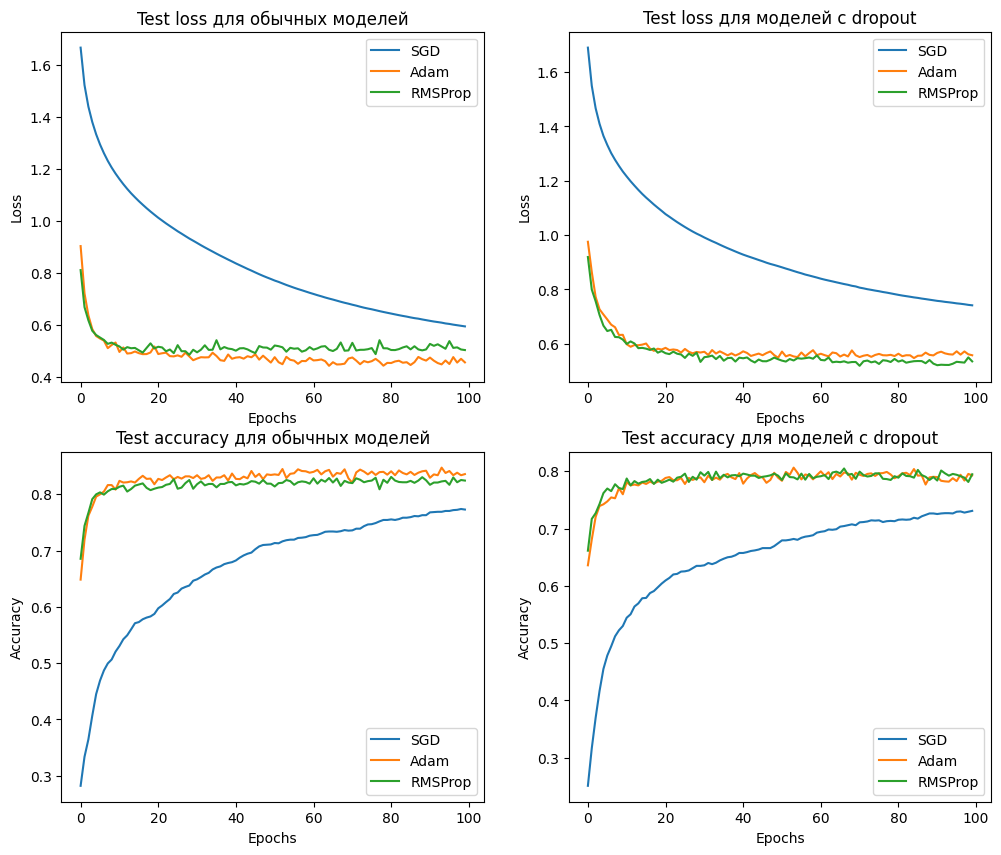

In [6]:
# Строим графики

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

for optim_name in optimizers.keys():
    ax1.plot(histories[optim_name].history[f"val_loss"], label=optim_name)
ax1.set_title('Test loss для обычных моделей')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

for optim_name in optimizers.keys():
    ax2.plot(histories[f"dropout_{optim_name}"].history[f"val_loss"], label=optim_name)
ax2.set_title('Test loss для моделей с dropout')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

for optim_name in optimizers.keys():
    ax3.plot(histories[optim_name].history[f"val_accuracy"], label=optim_name)
ax3.set_title('Test accuracy для обычных моделей')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.legend()

for optim_name in optimizers.keys():
    ax4.plot(histories[f"dropout_{optim_name}"].history[f"val_accuracy"], label=optim_name)
ax4.set_title('Test accuracy для моделей с dropout')
ax4.set_xlabel('Epochs')
ax4.set_ylabel('Accuracy')
ax4.legend()

plt.show()

### Вывод:
Простой оптимизатор SGD показывает наихудшие результаты. <br>
Более современные Adam и RMSProp показывают более быструю сходимость и более точные результаты: <br>
test accuracy оптимизаторов Adam и RMSProp превосходит test accuracy SGD на примерно 0.05. <br>
Между самими Adam и RMSProp особой разницы нет. <br>
Dropout в данном случае немного ухудшает результаты. <br>
Поскольку данные есть в достаточном кол-ве (N=10000) и не слишком зашумлены, <br>
то модель не переобучается и dropout оказывается бесполезен.

# Загружаем и предобрабатываем датасет MNIST

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [8]:
x_train = np.reshape(x_train / 255, (60000, 784))
x_test = np.reshape(x_test / 255, (10000, 784))
y_train = np.array(pd.get_dummies(y_train))
y_test = np.array(pd.get_dummies(y_test))

# Обучаем модели для задачи MNIST

In [20]:
# Обучаем модели без Dropout

histories_mnist = {}
optimizers = {"SGD": keras.optimizers.SGD(learning_rate=0.001),
              "Adam": keras.optimizers.Adam(learning_rate=0.001),
              "RMSProp": keras.optimizers.RMSprop(learning_rate=0.001)}

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential([
        keras.layers.Input((28 * 28, )),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(10, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers[optim_name],
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=50, batch_size=100, validation_data=(x_test, y_test))
    histories_mnist[optim_name] = history

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1297 - loss: 2.3349 - val_accuracy: 0.3183 - val_loss: 2.0996
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3654 - loss: 2.0436 - val_accuracy: 0.5304 - val_loss: 1.8276
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5686 - loss: 1.7636 - val_accuracy: 0.6713 - val_loss: 1.5296
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6823 - loss: 1.4741 - val_accuracy: 0.7374 - val_loss: 1.2691
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7385 - loss: 1.2355 - val_accuracy: 0.7784 - val_loss: 1.0676
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7769 - loss: 1.0482 - val_accuracy: 0.8090 - val_loss: 0.9192
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8044 - loss: 0.9081 - val_accuracy: 0.8271 - val_loss: 0.8120
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8199 - loss: 0.8143 - val_accuracy: 0.

In [21]:
# Обучаем модели с Dropout

optimizers = {"SGD": keras.optimizers.SGD(learning_rate=0.001),
              "Adam": keras.optimizers.Adam(learning_rate=0.001),
              "RMSProp": keras.optimizers.RMSprop(learning_rate=0.001)}

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential([
        keras.layers.Input((28 * 28, )),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.25),
        keras.layers.Dense(10, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers[optim_name],
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=50, batch_size=100, validation_data=(x_test, y_test))
    histories_mnist[f"dropout_{optim_name}"] = history

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1395 - loss: 2.2985 - val_accuracy: 0.3320 - val_loss: 2.0564
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2993 - loss: 2.0301 - val_accuracy: 0.5364 - val_loss: 1.7754
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4467 - loss: 1.7770 - val_accuracy: 0.6610 - val_loss: 1.5160
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5458 - loss: 1.5607 - val_accuracy: 0.7322 - val_loss: 1.3116
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6028 - loss: 1.3924 - val_accuracy: 0.7742 - val_loss: 1.1539
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6382 - loss: 1.2659 - val_accuracy: 0.7958 - val_loss: 1.0331
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6687 - loss: 1.1630 - val_accuracy: 0.8104 - val_loss: 0.9404
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6859 - loss: 1.0919 - val_accuracy: 0.

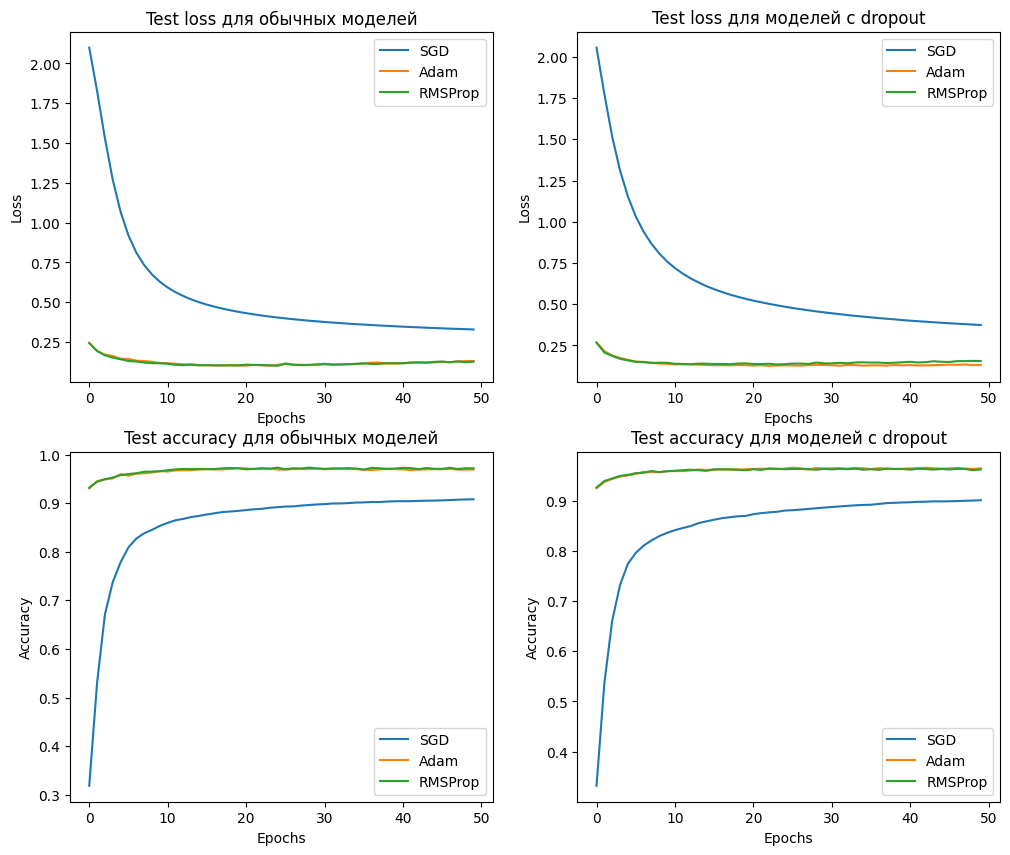

In [22]:
# Строим графики

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

for optim_name in optimizers.keys():
    ax1.plot(histories_mnist[optim_name].history[f"val_loss"], label=optim_name)
ax1.set_title('Test loss для обычных моделей')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

for optim_name in optimizers.keys():
    ax2.plot(histories_mnist[f"dropout_{optim_name}"].history[f"val_loss"], label=optim_name)
ax2.set_title('Test loss для моделей с dropout')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

for optim_name in optimizers.keys():
    ax3.plot(histories_mnist[optim_name].history[f"val_accuracy"], label=optim_name)
ax3.set_title('Test accuracy для обычных моделей')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.legend()

for optim_name in optimizers.keys():
    ax4.plot(histories_mnist[f"dropout_{optim_name}"].history[f"val_accuracy"], label=optim_name)
ax4.set_title('Test accuracy для моделей с dropout')
ax4.set_xlabel('Epochs')
ax4.set_ylabel('Accuracy')
ax4.legend()

plt.show()

### Вывод:
Результаты такие же, как и в случае с make_classification. <br>
SGD показывает наихудшие результаты, между Adam и RMSProp разницы нет. <br>
Поскольку модель не переобучается, то dropout бесполезен.